# Imports

In [1]:
import pandas as pd
import numpy as np
from multiprocessing import Pool
import random
import re
from defs import bfs_dfs_search, cluster_path_search

# Import combinations from itertools
from itertools import combinations
from itertools import permutations

import os
import math
from zgli.folder import Folder

import graphviz
from IPython.display import Image

import copy
import matplotlib.pyplot as plt

from IPython import display

from defs import bfs_dfs_search, cluster_path_search
from tqdm.notebook import tqdm

from IPython.display import display, clear_output

#### 0. Genereate example distance matrix

In [2]:
data_path = '0.example_data/10_example'               # Define data path to the folther containing the files
compressor = 'bzlib'                                  # Define the compressor to be used
output_path = '1.example_dms'                         # Define output path for distance_matrix.txt
folder = Folder(data_path)                            # Initialize Folder class
dm = folder.distance_matrix(compressor, dm_name='distmatrix_10', output_path = '1.example_dms/' )  # Compute distances

Compressing Files...


  0%|          | 0/10 [00:00<?, ?it/s]

Compressing Appended Files...


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

0_mouse.txt 0.0 0.941648 0.964551 0.967002 0.957282 0.960088 0.960252 0.967124 0.960965 0.965251
0_rat.txt 0.941648 0.0 0.966302 0.96132 0.958167 0.966924 0.958732 0.960157 0.955044 0.958172
1_graySeal.txt 0.964551 0.966302 0.0 0.77382 0.96105 0.954923 0.959818 0.964729 0.949891 0.942299
1_harborSeal.txt 0.967002 0.96132 0.77382 0.0 0.960009 0.953671 0.960252 0.962769 0.947334 0.94423
2_blueWhale.txt 0.957282 0.958167 0.96105 0.960009 0.0 0.854465 0.955691 0.960157 0.949342 0.95903
2_finWhale.txt 0.960088 0.966924 0.954923 0.953671 0.854465 0.0 0.953301 0.956238 0.948465 0.958172
3_chimpanzee.txt 0.960252 0.958732 0.959818 0.960252 0.955691 0.953301 0.0 0.8649 0.949175 0.961604
3_human.txt 0.967124 0.960157 0.964729 0.962769 0.960157 0.956238 0.8649 0.0 0.95123 0.959459
4_horse.txt 0.960965 0.955044 0.949891 0.947334 0.949342 0.948465 0.949175 0.95123 0.0 0.952166
5_cat.txt 0.965251 0.958172 0.942299 0.94423 0.95903 0.958172 0.961604 0.959459 0.952166 0.0



#### 1. Read distance matrix

In [3]:
def read_distance_matrix(dm_path, file_extension = '.txt'):
    
    """
        Read distance matrix of the same format outputed by folder.distance_matrix.

        Parameters
        ----------
        dm_path : string
            Distance matrix file path.
        
        file_extension : string, default = '.txt'
            Distance matrix file extension.

        Returns
        -------
        dm : array_like
            Distance matrix saved in an numpy array.
            
        labels : array_like
            The labels of all objects inside the distance matrix.
    """

    data = np.loadtxt(dm_path, delimiter = file_extension, dtype=str)
    labels = data.T[0]
    dm = data.T[1:].T
    new_dm = []
    for i in dm:
        i[0].split(' ')
        new_dm.append(i[0].split(' ')[1:])
    dm = np.array(new_dm).astype(float)
    return dm, labels

In [4]:
dm, leaf_labels = read_distance_matrix('1.example_dms/distmatrix_10.txt', file_extension = '.txt')

#### 2. Generate Random Tree

In [5]:
def generate_random_tree(leaf_labels):
    
    """
        Generates a random tree from leaf_labels.

        Parameters
        ----------
        df : array_like
            A list with the labels of the objects to be put in a trenary tree structure.

        Returns
        -------
        tree_dict : dict
            A dictionary containing all the inner tree nodes and its connections to other inner nodes/ leafs.

        Notes
        --------
        Function returns error if leafs are less than 6.
    """
    
    if len(leaf_labels) < 6:
        raise Exception("There must be at least six objects to cluster.")
    
    inner_node_labels = np.array([])
    tree_dict = {}

    # Initialize inner nodes
    for n in range(0,len(leaf_labels)-2):
        inner_node_labels = np.append(inner_node_labels, ('n' + str(n)))

    # Tree dict
    for n in inner_node_labels:
        tree_dict[n] = np.array([])

    # print(f'leaf_lables: {leaf_labels}')
    # print(f'inner_node_labels: {inner_node_labels}')
    # print(f'tree_dict: {tree_dict}')

    # Create inner_node connections
    nodes_to_use = inner_node_labels.copy()
    for index,node in enumerate(inner_node_labels):

        if len(nodes_to_use) == 0:
            break

        if node in nodes_to_use:
            index = np.argwhere(nodes_to_use == node)
            nodes_to_use = np.delete(nodes_to_use, index)

        # Initialize root node
        if index == 0:

            # Roll for number of inner_node connections
            possible_rolls = np.arange(1,4)
            number_of_connections = np.random.choice(possible_rolls)

            # Create number of connections rolled
            for connection in range(number_of_connections):
                node_to_connect = nodes_to_use[0]
                nodes_to_use = np.delete(nodes_to_use, 0)
                tree_dict[node] = np.append(tree_dict[node], node_to_connect)
                tree_dict[node_to_connect] = np.append(tree_dict[node_to_connect], node)

        elif index != 0 and len(tree_dict[node]) < 3:

            # Roll for number of inner_node connection
            possible_rolls = np.arange(1,4-len(tree_dict[node]))
            number_of_connections = np.random.choice(possible_rolls)

            if number_of_connections > len(nodes_to_use):
                number_of_connections = len(nodes_to_use)

            # Create number of connections rolled
            for connection in range(number_of_connections):
                node_to_connect = nodes_to_use[0]
                nodes_to_use = np.delete(nodes_to_use, 0)
                tree_dict[node] = np.append(tree_dict[node], node_to_connect)
                tree_dict[node_to_connect] = np.append(tree_dict[node_to_connect], node)
    
    inner_node_dict = tree_dict.copy()
    
    # Add leafs to inner_nodes
    leaf_dict = {}
    
    for node in tree_dict.keys():

        number_of_leafs = range(3 - len(tree_dict[node]))

        for n in number_of_leafs:
            leaf = np.random.choice(leaf_labels,1)
            leaf_index = np.where(leaf_labels == leaf)
            leaf_labels = np.delete(leaf_labels,leaf_index)
            tree_dict[node] = np.append(tree_dict[node], leaf)
            leaf_dict[leaf[0]] = node
            
    return inner_node_dict, leaf_dict

In [6]:
inner_node_dict, leaf_dict = generate_random_tree(leaf_labels)

In [7]:
def get_graph(inner_node_dict, leaf_dict):
    
    """
        Generates graph dictionary from the inner node and leaf dictionaries.

        Parameters
        ----------
        inner_node_dict : dict
            Dictionary with all inner node connections.
        
        leaf_dict: dict
            Dictionary with all leaf node connections to their respective inner nodes.

        Returns
        -------
        graph : dict
            A dictionary with the full structure of the tree represented by the inner nodes and leafs.
    """
        
    graph = inner_node_dict.copy()
    for leaf in leaf_dict:
        graph[leaf_dict[leaf]] = np.append(graph[leaf_dict[leaf]], leaf)
        graph[leaf] = np.array([leaf_dict[leaf]])
    return graph

In [8]:
# get_graph(inner_node_dict, leaf_dict)

#### 3. Swap Leafs

In [9]:
def swap_leafs(leaf_dict):
    
    """
        Swap two random leafs with each other.

        Parameters
        ----------
        leaf_dict: dict
            Dictionary with all leaf node connections to their respective inner nodes.

        Returns
        -------
        leaf_dict_tmp : dict
            A dictionary with the new leaf node connections to their respective inner nodes.
        
        random_leafs : array_like
            The labels of the leafs swaped.
    """
    
    do = True
    while do:
        
        leaf_dict_tmp = leaf_dict.copy()
        random_leafs = np.random.choice(list(leaf_dict_tmp.keys()),2,replace=False)
        node_zero = leaf_dict_tmp[random_leafs[0]]
        node_one = leaf_dict_tmp[random_leafs[1]]

        # If they are not connected to the same node don't repeat the loop
        if node_zero != node_one:
            do = False

            leaf_dict_tmp[random_leafs[0]] = node_one
            leaf_dict_tmp[random_leafs[1]] = node_zero

        return leaf_dict_tmp, random_leafs

In [10]:
# # Swap and make graph
# leaf_dict, random_leafs = swap_leafs(leaf_dict)
# print(random_leafs)
# graph = get_graph(inner_node_dict, leaf_dict)

# dot = graphviz.Digraph('round-table', comment='The Round Table')  

# for key,values in graph.items():
#     dot.node(key,key)
#     for v in values:
#         dot.edge(key,v)

# dot.render(directory='doctest-output').replace('\\', '/')
# dot

In [11]:
inner_node_dict

{'n0': array(['n1', 'n2'], dtype='<U32'),
 'n1': array(['n0', 'n3', 'n4'], dtype='<U32'),
 'n2': array(['n0', 'n5', 'n6'], dtype='<U32'),
 'n3': array(['n1', 'n7'], dtype='<U32'),
 'n4': array(['n1'], dtype='<U32'),
 'n5': array(['n2'], dtype='<U32'),
 'n6': array(['n2'], dtype='<U32'),
 'n7': array(['n3'], dtype='<U32')}

#### 4. Swap Nodes

In [12]:
def get_paths_between_pairs(pairs, graph, processes):
    
    """
        Get paths between pairs of nodes.

        Parameters
        ----------
        pairs: array_like
            An array with the pairs of nodes which paths are to be found.
            
        graph : dict
            A dictionary with the full structure of the tree represented by the inner nodes and leafs.
            
        processes: int
            Number of processes to be used in the paralelization of this function.
            
        Returns
        -------
        pairs_with_paths : dict
            A dictionary with all the node pairs and the respective path between them.
    """
    
    # Create Arguments for search function
    argument_list = [[graph, pair[0], pair[1], 1] for pair in pairs]
    p = Pool()
    paths = p.map(bfs_dfs_search,argument_list)
    p.close()
    p.join()
    
    # Initialize dictionary with leaf pairs and their respective paths
    pairs_with_paths = {}
    for i,pair in enumerate(pairs):
        pairs_with_paths[pair] = paths[i]
    
    return pairs_with_paths

In [13]:
def get_path_between_pair(pair,graph):
    path = bfs_dfs_search([graph, pair[0], pair[1], 0])
    return {tuple(pair): path}

In [14]:
def swap_nodes(inner_node_dict):
    
    """
        Swap to random nodes.

        Parameters
        ----------
        inner_node_dict: dict
            Dictionary with all inner node connections.

        Returns
        -------
        inner_node_dict_tmp: dict
            Dictionary with all new inner node connections after node swaping.
        
        random: array_like
            The labels of the nodes swaped.
    """
    
    inner_node_dict_tmp = copy.deepcopy(inner_node_dict)

    # Get only nodes with at least 2 connections
    two_connection_nodes = [node for node,connections in inner_node_dict_tmp.items() if len(connections) > 1]

    # Select two nodes at random
    do = True
    random_nodes = None
    node_pairs = None
    node_pairs_with_paths = None
    
    while do:
        
        # Select random nodes
        random_nodes = np.random.choice(two_connection_nodes,2,replace=False)

        # Get the path between them 
        node_pairs = random_nodes
        node_pairs_with_paths = get_path_between_pair(node_pairs, inner_node_dict_tmp)
        
        # check if nodes are not connected
        if len(node_pairs_with_paths[tuple(random_nodes)]) > 0:
            do = False

    # Get swap options
    possible_nodes_zero = [node for node in inner_node_dict_tmp[random_nodes[0]] if node not in node_pairs_with_paths[tuple(random_nodes)] and node != random_nodes[1]]
    possible_nodes_one = [node for node in inner_node_dict_tmp[random_nodes[1]] if node not in node_pairs_with_paths[tuple(random_nodes)] and node != random_nodes[0]]

    # Swap nodes
    swap_zero = np.random.choice(possible_nodes_zero)
    swap_one = np.random.choice(possible_nodes_one)

    # Swap
    index = np.argwhere(inner_node_dict_tmp[random_nodes[0]]  == swap_zero)
    inner_node_dict_tmp[random_nodes[0]][index] =  swap_one

    index = np.argwhere(inner_node_dict_tmp[random_nodes[1]]  == swap_one)
    inner_node_dict_tmp[random_nodes[1]][index] =  swap_zero

    index = np.argwhere(inner_node_dict_tmp[swap_zero]  == random_nodes[0])
    inner_node_dict_tmp[swap_zero][index] = random_nodes[1]

    index = np.argwhere(inner_node_dict_tmp[swap_one]  == random_nodes[1])
    inner_node_dict_tmp[swap_one][index] = random_nodes[0]

    return inner_node_dict_tmp, [swap_zero, swap_one]

In [15]:
# inner_node_dict_tmp, [swap_zero, swap_one] = swap_nodes(inner_node_dict)
# print([swap_zero, swap_one])

#### 5. Swap leaf with node

In [16]:
def get_leaf_node_pairs(possible_nodes, possible_leafs):
    leaf_node_pairs = []
    for node in possible_nodes:
        for leaf in possible_leafs:
            leaf_node_pairs.append((node,leaf))
    return leaf_node_pairs

In [17]:
def swap_leaf_with_node(inner_node_dict, leaf_dict):
    
    """
        Swap a random node with a randopm leaf.

        Parameters
        ----------
        inner_node_dict: dict
            Dictionary with all inner node connections.
            
        leaf_dict: dict
            Dictionary with all leaf node connections to their respective inner nodes.

        Returns
        -------
        inner_node_dict_tmp: dict
            Dictionary with all new inner node connections after node swaping.
            
        leaf_dict_tmp : dict
            A dictionary with the new leaf node connections to their respective inner nodes.
        
        random_nodes: array_like
            The labels of the nodes and leaf swaped.
    """
    
    inner_node_dict_tmp = copy.deepcopy(inner_node_dict)
    leaf_dict_tmp = leaf_dict.copy()

    # Get only nodes with at least 2 connections
    two_connection_nodes = [node for node,connections in inner_node_dict_tmp.items() if len(connections) > 1]

    # Get nodes with at least 1 leaf
    leafs = list(leaf_dict_tmp.keys())

    # Get the path between them 
    node_pairs = get_leaf_node_pairs(two_connection_nodes, leafs)

    # Select pair at random
    do = True
    node_leaf_pair = None
    node_pairs_with_paths = None
    node_leaf = None
    leaf = None

    while do:

        # Select random nodes
        node_leaf_pair  = node_pairs[np.random.choice(list(range(len(node_pairs))))]
        leaf = node_leaf_pair[1]
        
        # Get paths
        node_pairs_with_paths = get_path_between_pair(node_leaf_pair, get_graph(inner_node_dict_tmp, leaf_dict_tmp))
        node_leaf = leaf_dict_tmp[node_leaf_pair[1]]

        # check if nodes are not connected
        if len(node_pairs_with_paths[tuple(node_leaf_pair)]) > 0:
            do = False

    possible_nodes = [node for node in inner_node_dict_tmp[node_leaf_pair[0]] if node not in node_pairs_with_paths[tuple(node_leaf_pair)] and node != node_leaf]
    swap_node = np.random.choice(possible_nodes)

    # Swap
    inner_node_dict_tmp[node_leaf] = np.append(inner_node_dict_tmp[node_leaf], swap_node)
    inner_node_dict_tmp[swap_node] = np.append(inner_node_dict_tmp[swap_node], node_leaf)

    index = np.argwhere(inner_node_dict_tmp[node_leaf_pair[0]]  == swap_node)
    inner_node_dict_tmp[node_leaf_pair[0]] = np.delete(inner_node_dict_tmp[node_leaf_pair[0]], index)

    index = np.argwhere(inner_node_dict_tmp[swap_node]  == node_leaf_pair[0])
    inner_node_dict_tmp[swap_node] = np.delete(inner_node_dict_tmp[swap_node], index)

    leaf_dict_tmp[leaf] = node_leaf_pair[0]
    
    return inner_node_dict_tmp, leaf_dict_tmp, [swap_node, leaf]

In [18]:
# inner_node_dict, leaf_dict, node_leaf = swap_leaf_with_node(inner_node_dict, leaf_dict)
# print(node_leaf)
# graph = get_graph(inner_node_dict, leaf_dict)

# dot = graphviz.Digraph('round-table', comment='The Round Table')  

# for key,values in graph.items():
#     dot.node(key,key)
#     for v in values:
#         dot.edge(key,v)

# dot.render(directory='doctest-output').replace('\\', '/')
# dot

#### 6. Make Tree

In [19]:
def generate_leaf_pairs(leaf_labels):
    
    """
        Generates leaf pair combinations (without repetition).

        Parameters
        ----------
        leaf_labels: array_like
            A list with all leaf labels.
            
       Returns
        -------
        leaf_pairs: array_like
            A list containing leaf pair combinations (without repetition).
    """
    
    return tuple(combinations(leaf_labels, 2))

In [20]:
def generate_all_quartets(leaf_labels):
    
    """
        Generates leaf pair combinations (without repetition).

        Parameters
        ----------
        leaf_labels: array_like
            A list with all leaf labels.
            
       Returns
        -------
        leaf_pairs: array_like
            A list containing all leaf quartet combinations (without repetition).
    """
    
    leaf_quartets = combinations(leaf_labels, 4)
    all_quartets = []
    for quartet in leaf_quartets:
        c = tuple(combinations(quartet, 2))
        all_quartets.append((c[0],c[5]))
        all_quartets.append((c[1],c[4]))
        all_quartets.append((c[2],c[3]))
        
    return all_quartets

In [21]:
def get_leaf_pairs_with_paths(leaf_pairs, graph, processes):
    
    """
        Get paths between pairs of nodes.

        Parameters
        ----------
        leaf_pairs: array_like
            An array with the pairs of leaf nodes which paths are to be found.
            
        graph : dict
            A dictionary with the full structure of the tree represented by the inner nodes and leafs.
            
        processes: int
            Number of processes to be used in the paralelization of this function.
            
        Returns
        -------
        leaf_pairs_with_paths : dict
            A dictionary with all the leaf node pairs and the respective mother nodes.
    """
    
    # Create Arguments for search function
    argument_list = [[graph, pair[0], pair[1], 1] for pair in leaf_pairs]
    p = Pool()
    paths = p.map(bfs_dfs_search,argument_list)
    p.close()
    p.join()
    
    # Initialize dictionary with leaf pairs and their respective paths
    leaf_pairs_with_paths = {}
    for i,pair in enumerate(leaf_pairs):
        leaf_pairs_with_paths[pair] = paths[i]
    
    return leaf_pairs_with_paths

In [22]:
def find_consistent_quartets(all_quartets, leaf_pairs_with_paths):
    
    """
        Get paths between pairs of nodes.

        Parameters
        ----------
        all_quartets: array_like
            An array with all tree quartets.
            
        leaf_pairs_with_paths : dict
            A dictionary with all the leaf node pairs and the respective mother nodes.
            
        Returns
        -------
        consistent_quartets : array_like
            A list with all consistent quartets.
    """
     
    consistent_quartets = []
    for quartet in all_quartets:

        # Define quartets
        pair_zero = tuple(quartet[0])
        pair_one = tuple(quartet[1])

        # Check if paths do not intercept
        if len(np.intersect1d(leaf_pairs_with_paths[pair_zero], leaf_pairs_with_paths[pair_one])) == 0:
            consistent_quartets.append(quartet)
            
    return consistent_quartets

In [23]:
def compute_quartet_cost(dm, labels, quartet):
    
    """
        Compute quartet cost of a single quartet.

        Parameters
        ----------
        dm: array_like
            Distance matrix saved in an numpy array.
        
        labels: array_like
            An array with all leaf labels.
            
        quartet: array_like
            A list with all nodes in the given quartet.
            
        Returns
        -------
        quartet_cost: int
            Quartet cost of given quartet.
    """
    
    pair_one = np.array(quartet[0])
    pair_two = np.array(quartet[1])
    
    pair_one_i = [np.argwhere(labels == node)[0][0] for node in pair_one]
    pair_two_i = [np.argwhere(labels == node)[0][0] for node in pair_two]

    cost_one = dm[pair_one_i[0]][pair_one_i[1]]
    cost_two = dm[pair_two_i[0]][pair_two_i[1]]
    
    return cost_one + cost_two

In [24]:
def compute_min_max_tree_costs(all_quartets,dm,labels):
    
    """
        Compute the minimum and maximum cost a tree can have for a given distance matrix.

        Parameters
        ----------
        all_quartets: array_like
            A list with all quartets of the given distance matrix.
            
        dm: array_like
            Distance matrix saved in an numpy array.
        
        labels: array_like
            An array with all leaf labels.

        Returns
        -------
        min_tree_cost: int
            Minimum possible tree cost for given distance matrix.
            
        max_tree_cost: int
            Maximum possible tree cost for given distance matrix.
    """
    
    min_tree_cost = 0
    max_tree_cost = 0 

    for three_quartets in np.array(all_quartets).reshape(int(len(all_quartets)/3),3,2,2):
        costs = []
        for quartet in three_quartets:
            costs.append(compute_quartet_cost(dm,labels,quartet))
        min_tree_cost += min(costs)
        max_tree_cost += max(costs)
        
    return min_tree_cost, max_tree_cost

In [25]:
def compute_tree_score(consistent_quartets, dm, labels, min_tree_cost, max_tree_cost):
    
    """
        Compute tree cost given a list of consistent quartets.

        Parameters
        ----------
        consistent_quartets: array_like
            A list with all consistent quartets.
            
        dm: array_like
            Distance matrix saved in an numpy array.
        
        labels: array_like
            An array with all leaf labels.
            
        min_tree_cost: int
            Minimum possible tree cost for given distance matrix.
            
        max_tree_cost: int
            Maximum possible tree cost for given distance matrix.

        Returns
        -------
        tree_cost: int
            Tree cost of given consistent quartets.
    """
    
    cost = 0
    for quartet in consistent_quartets:
        cost += compute_quartet_cost(dm, labels,quartet)

    # return cost
    return (max_tree_cost - cost) / (max_tree_cost - min_tree_cost)

In [26]:
def save_current_tree(graph):
    
    """
        Save colorless tree of given graph in tree folder.

        Parameters
        ----------
        graph: dict
            A dictionary with the full structure of the tree represented by the inner nodes and leafs.

        Returns
        -------
        graph: graphviz.dot
            Dot with tree structure.
            
        file_name: string
            File name of the tree png image.
    """
    
    graph_tmp = graph.copy()
    g = graphviz.Graph('gray_tree', 
                       strict = True, 
                       filename = 'gray_tree.gv',
                       engine = 'sfdp',
                       node_attr = {'style': 'filled,dashed', 'fontname':"Bahnschrift"})

    for key,values in graph_tmp.items():
        for v in values:
            node_color = 'snow3'
            g.node(key,key, style='filled', color = node_color, fillcolor = node_color)
            g.edge(key,v,color = node_color)

    filename = g.render(directory='trees', format='png').replace('\\', '/')

    return g, filename

In [27]:
def compute_leaf_swap_tmp_paths(leafs,leaf_pairs_with_paths, in_dict, lf_dict):
    
    """
        Compute leaf swap and update leaf paths.

        Parameters
        ----------
        leafs: array_like
            An array the two swapped leafs.
            
        leaf_pairs_with_paths: dict
            A dictionary with all the leaf node pairs and the respective mother nodes.
            
        in_dict: dict
            Dictionary with all inner node connections.
            
        lf_dict: dict
            Dictionary with all leaf node connections to their respective inner nodes.

        Returns
        -------
        leaf_pairs_with_paths : dict
            A dictionary with all the new leaf node pairs and the respective mother nodes.
    """
    
    leaf_pairs_with_paths_tmp = leaf_pairs_with_paths.copy()
    pairs_to_update = []
    for pair in leaf_pairs_with_paths_tmp.keys():
        if leafs[0] in pair or leafs[1] in pair:
            pairs_to_update.append(pair)

    pairs_to_update_with_paths = get_paths_between_pairs(pairs_to_update, get_graph(in_dict, lf_dict), 10)
    for k,v in pairs_to_update_with_paths.items():
        leaf_pairs_with_paths_tmp[k] = v

    return leaf_pairs_with_paths_tmp

In [28]:
def compute_node_swap_tmp_paths(nodes,leaf_pairs_with_paths, in_dict, lf_dict):
    
    """
        Compute node swap and update leaf paths.

        Parameters
        ----------
        nodes: array_like
            An array the two swapped nodes.
            
        leaf_pairs_with_paths: dict
            A dictionary with all the leaf node pairs and the respective mother nodes.
            
        in_dict: dict
            Dictionary with all inner node connections.
            
        lf_dict: dict
            Dictionary with all leaf node connections to their respective inner nodes.

        Returns
        -------
        leaf_pairs_with_paths : dict
            A dictionary with all the new leaf node pairs and the respective mother nodes.
    """
    
    leaf_pairs_with_paths_tmp = leaf_pairs_with_paths.copy()
    pairs_to_update = []
    for pair, path in leaf_pairs_with_paths_tmp.items():
        if nodes[0] in path or nodes[1] in path:
            pairs_to_update.append(pair)

    pairs_to_update_with_paths = get_paths_between_pairs(pairs_to_update, get_graph(in_dict, lf_dict), 10)
    for k,v in pairs_to_update_with_paths.items():
        leaf_pairs_with_paths_tmp[k] = v

    return leaf_pairs_with_paths_tmp

In [29]:
def compute_node_leaf_swap_tmp_paths(node_leaf,leaf_pairs_with_paths, in_dict, lf_dict):
    
    """
        Compute node swap with leaf and update leaf paths.

        Parameters
        ----------
        node_leaf: array_like
            An array with the node and leaf swaped.
            
        leaf_pairs_with_paths: dict
            A dictionary with all the leaf node pairs and the respective mother nodes.
            
        in_dict: dict
            Dictionary with all inner node connections.
            
        lf_dict: dict
            Dictionary with all leaf node connections to their respective inner nodes.

        Returns
        -------
        leaf_pairs_with_paths : dict
            A dictionary with all the new leaf node pairs and the respective mother nodes.
    """
    
    leaf_pairs_with_paths_tmp = leaf_pairs_with_paths.copy()
    pairs_to_update = []
    for pair, path in leaf_pairs_with_paths.items():
        if (node_leaf[0] in path) or (node_leaf[1] in pair):
            pairs_to_update.append(pair)

    pairs_to_update_with_paths = get_paths_between_pairs(pairs_to_update, get_graph(in_dict, lf_dict), 10)
    for k,v in pairs_to_update_with_paths.items():
        leaf_pairs_with_paths_tmp[k] = v

    return leaf_pairs_with_paths_tmp

In [30]:
def make_tree(dm, leaf_labels, processes):
    
    """
        Search for the best tree of a given distance matrix.

        Parameters
        ----------
        dm: array_like
            Distance matrix saved in an numpy array.
            
        leaf_labels: array_like
            An array with all leaf labels.
            
        processes: int
            Number of processes to be used in the paralelization of this function.
        
        Returns
        -------
        inner_node_dict : dict
            Dictionary with all inner node connections.
        
        leaf_dict: dict
            Dictionary with all leaf node connections to their respective inner nodes.
            
        Outputs
        -------
        gray_tree: png
            For every new best tree found, the gray_tree image is updated inside the tree folder.
    """

    # Generate random tree
    inner_node_dict, leaf_dict = generate_random_tree(leaf_labels)

    # Compute initial cost
    leaf_pairs = generate_leaf_pairs(leaf_labels)
    all_quartets = generate_all_quartets(leaf_labels)
    leaf_pairs_with_paths = get_leaf_pairs_with_paths(leaf_pairs, get_graph(inner_node_dict, leaf_dict), processes)
    consistent_quartets = find_consistent_quartets(all_quartets, leaf_pairs_with_paths)
    min_tree_cost, max_tree_cost = compute_min_max_tree_costs(all_quartets,dm,leaf_labels)
    tree_score = compute_tree_score(consistent_quartets, dm, leaf_labels, min_tree_cost, max_tree_cost)

    leaf_pairs_with_paths_tmp = None
    graph = None
    do = True
    tree_count = 1
    criterion = [1]

    while (tree_count < 6) or (tree_score < 0.98):

        graph_0 = get_graph(inner_node_dict,leaf_dict)

        # Mutate tree
        mutation = np.random.choice([0,1,2])

        if mutation == 0:

            # Swap 2 Leafs
            leaf_dict_tmp, leafs = swap_leafs(leaf_dict)
            inner_node_dict_tmp = inner_node_dict.copy()

            # Get temporary paths after leaf swap
            leaf_pairs_with_paths_tmp = compute_leaf_swap_tmp_paths(leafs,leaf_pairs_with_paths, inner_node_dict_tmp, leaf_dict_tmp)
            # leaf_pairs_with_paths_tmp = get_leaf_pairs_with_paths(leaf_pairs, get_graph(inner_node_dict_tmp, leaf_dict_tmp), 10)

        elif mutation == 1:

            # Swap 2 Nodes
            inner_node_dict_tmp, inner_nodes = swap_nodes(inner_node_dict)
            leaf_dict_tmp = leaf_dict.copy()

            # Get temporary paths after node swap
            leaf_pairs_with_paths_tmp = compute_node_swap_tmp_paths(inner_nodes,leaf_pairs_with_paths, inner_node_dict_tmp, leaf_dict_tmp)

            # leaf_pairs_with_paths_tmp = get_leaf_pairs_with_paths(leaf_pairs, get_graph(inner_node_dict_tmp, leaf_dict_tmp), 10)

        elif mutation == 2:

            # Swap node with leaf
            inner_node_dict_tmp, leaf_dict_tmp, node_leaf = swap_leaf_with_node(inner_node_dict, leaf_dict)

            # Get temporary paths after swaping node with leaf
            # leaf_pairs_with_paths_tmp = compute_node_leaf_swap_tmp_paths(node_leaf,leaf_pairs_with_paths, inner_node_dict_tmp, leaf_dict_tmp)
            leaf_pairs_with_paths_tmp = get_leaf_pairs_with_paths(leaf_pairs, get_graph(inner_node_dict_tmp, leaf_dict_tmp), 10)

        # Find all consistent quartets
        consistent_quartets = find_consistent_quartets(all_quartets, leaf_pairs_with_paths_tmp)

        # Compute temporary tree Score
        tree_score_tmp = compute_tree_score(consistent_quartets, dm, leaf_labels, min_tree_cost, max_tree_cost)

        # Update tree if score improves
        if tree_score_tmp > tree_score:

            # Append to stopage convergence criterion
            criterion.append(abs(tree_score_tmp - tree_score) / tree_score)

            # Update tree variables
            inner_node_dict = inner_node_dict_tmp
            leaf_dict = leaf_dict_tmp
            leaf_pairs_with_paths = leaf_pairs_with_paths_tmp

            # Update tree score
            tree_score = tree_score_tmp

            # Get graph
            graph_1 = get_graph(inner_node_dict,leaf_dict)
            dot,filename = save_current_tree(graph_1)

            # Plot tree
            image = plt.imread("trees/gray_tree.gv.png")
            figure, ax = plt.subplots(figsize=(10, 10))
            im = ax.imshow(image)
            ax.set_yticklabels([])
            ax.set_xticklabels([])
            ax.set_xticks([])
            ax.set_yticks([])
            clear_output(wait = True)
            display(figure)    
            
            # display.clear_output(wait=True)
            # display.display(plt.gcf())

        tree_count = tree_count + 1
        print(f'Tree Score: {tree_score:.5f} Mutation: {mutation} Trees Generates: {tree_count} Crieterion: {criterion[-1]:.5f}', end='\r')
        

    return inner_node_dict, leaf_dict

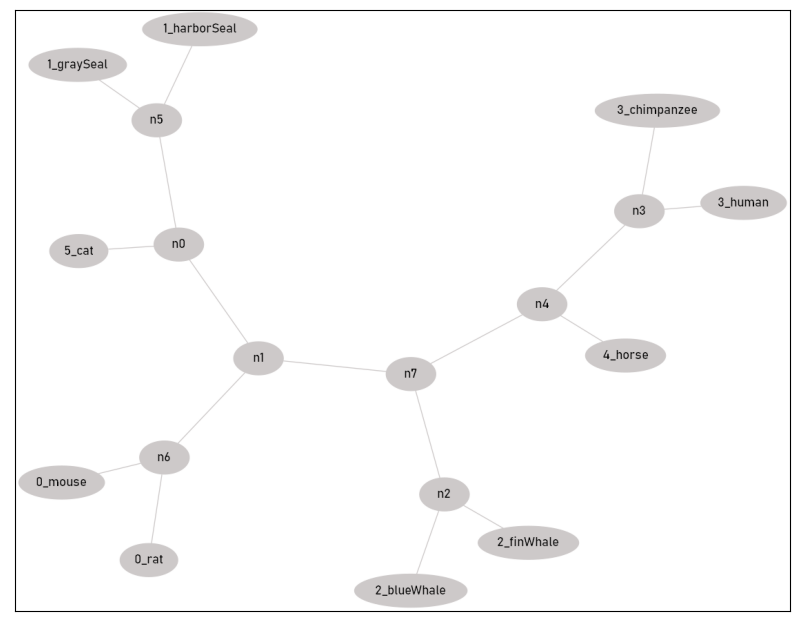

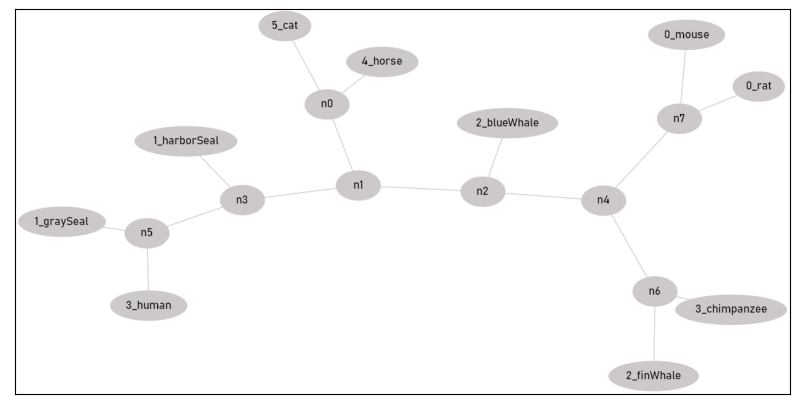

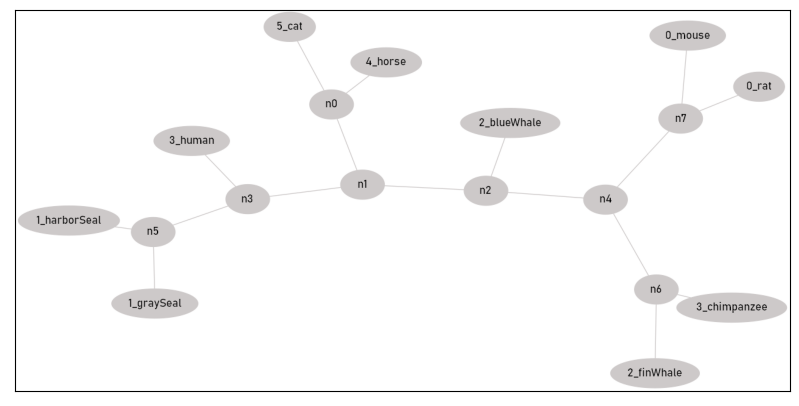

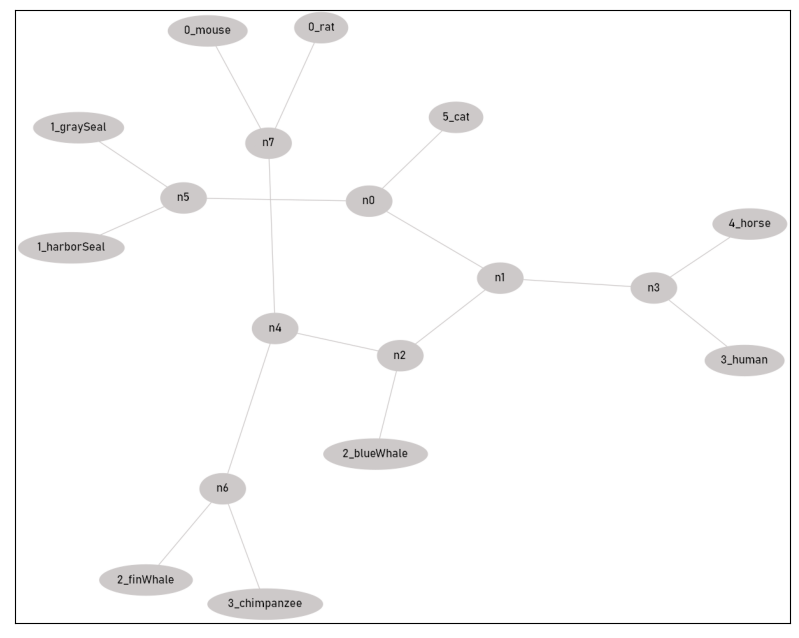

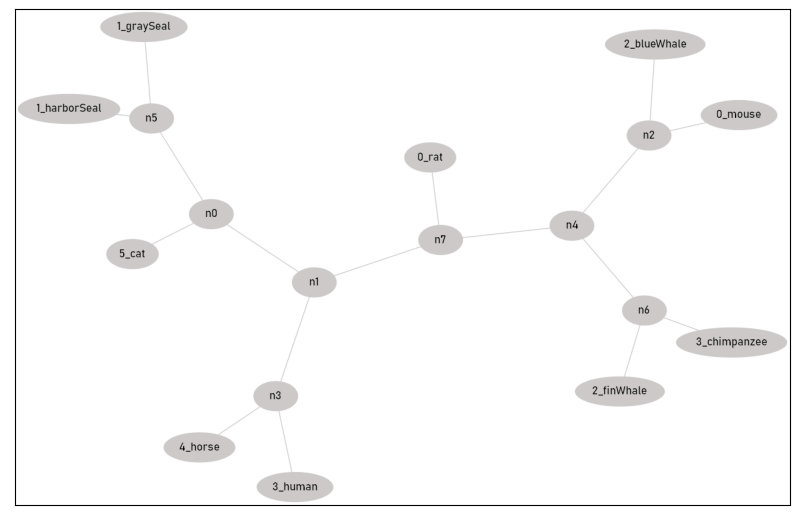

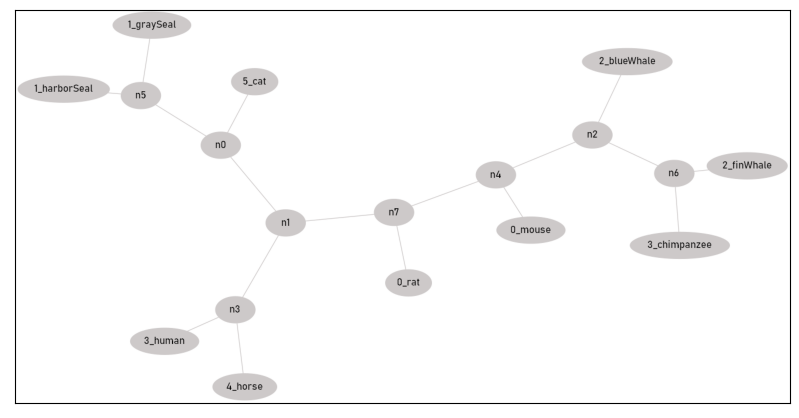

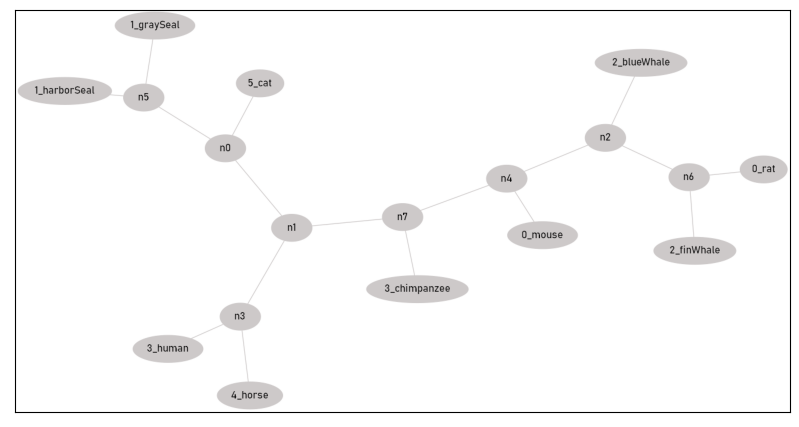

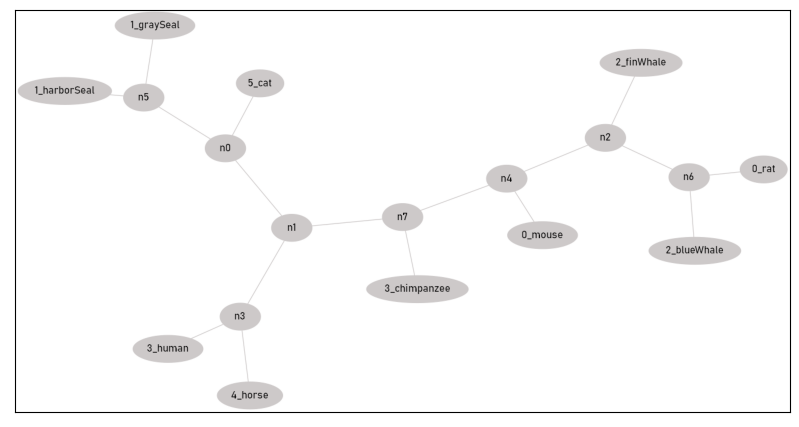

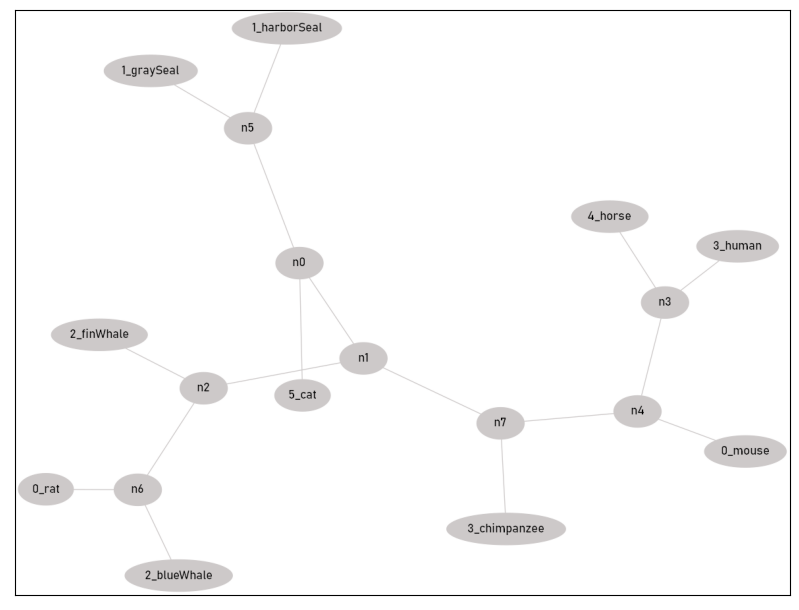

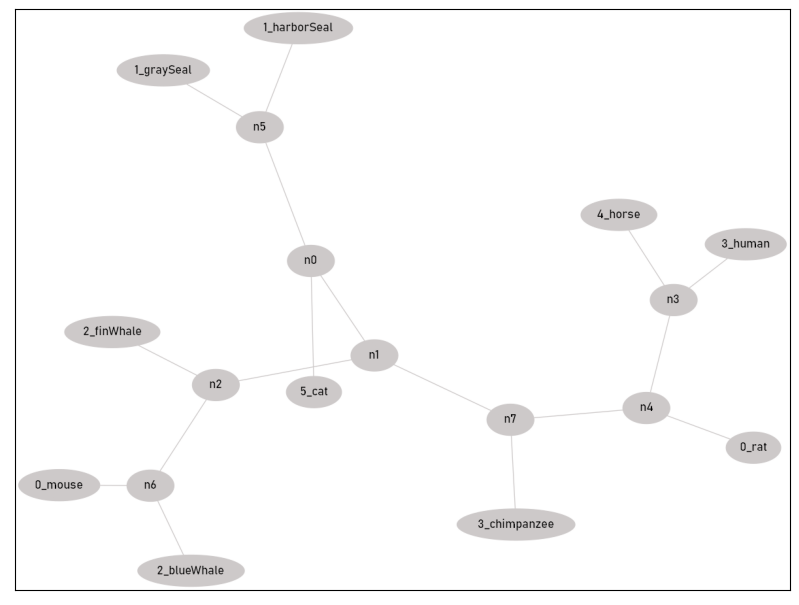

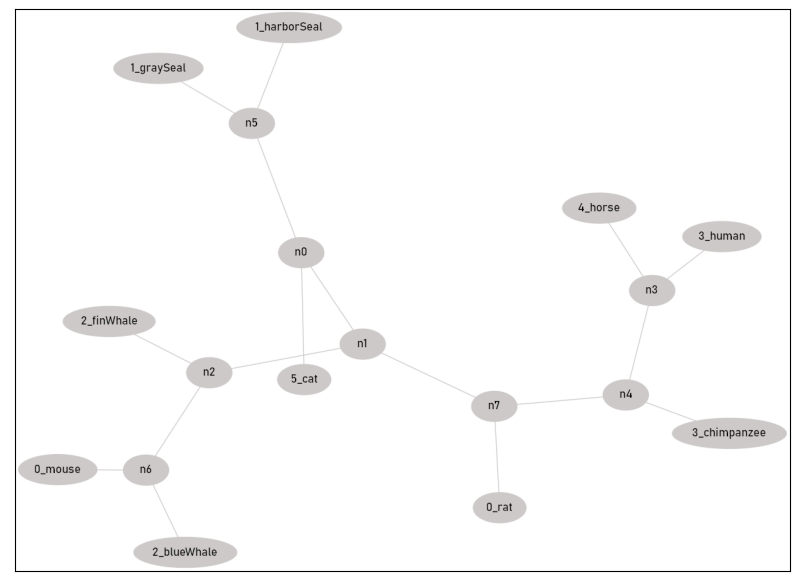

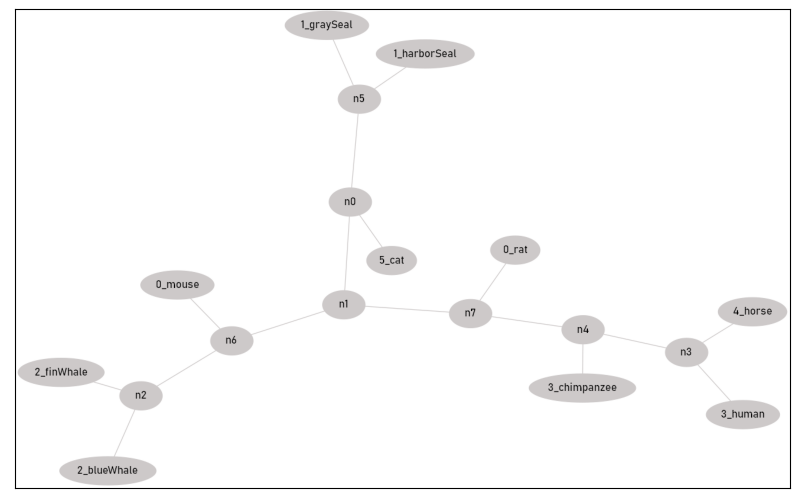

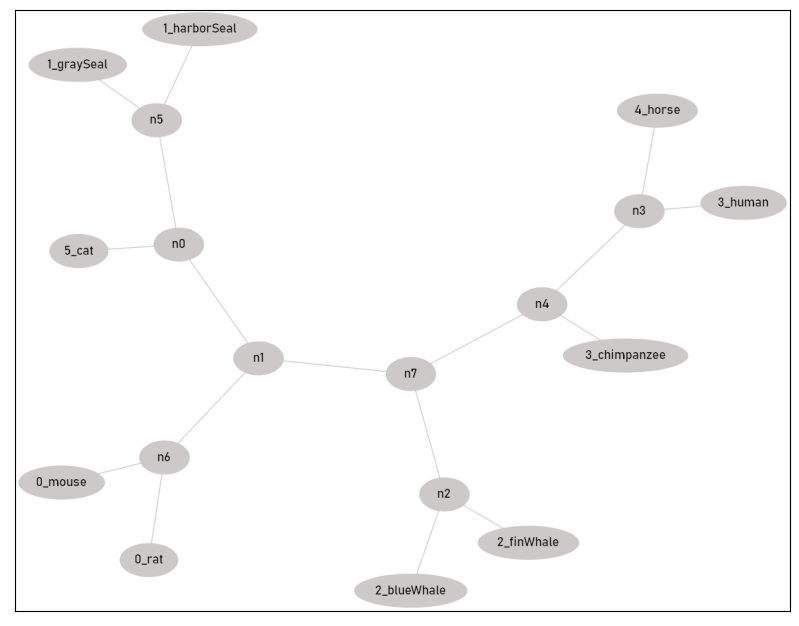

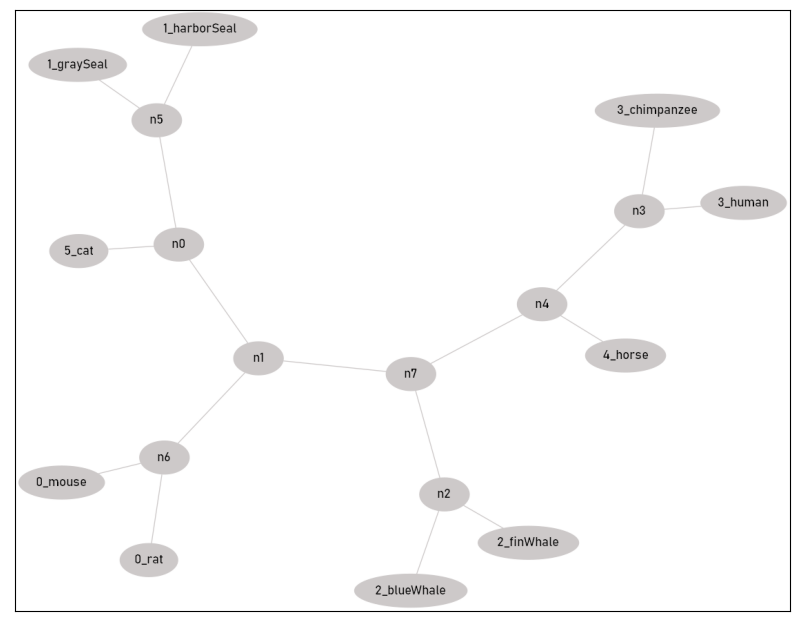

In [31]:
# Read distance matrix
dm, leaf_labels = read_distance_matrix('1.example_dms/distmatrix_10.txt', file_extension = '.txt')
processes = 10

inner_node_dict, leaf_dict = make_tree(dm, leaf_labels, processes)

In [32]:
def initialize_clusters(leaf_dict):
    
    """
        Search for the best tree of a given distance matrix.

        Parameters
        ----------
        leaf_dict: dict
            Dictionary with all leaf node connections to their respective inner nodes.

        Returns
        -------
        clusters: dict
            Dictionary with all clusters.
        
        cluster_count: int
            Current number of clusters inside the dictionary.
    """
    
    count = 0
    clusters = {}
    for leaf,node in leaf_dict.items():
        cluster_id = count
        mother_node = leaf
        cluster = [leaf]
        clusters[count] = [cluster_id,mother_node,cluster]
        count += 1
    return clusters, count-1

In [33]:
def get_closest_clusters(pairs, graph, processes):
    
    """
        Search for the best tree of a given distance matrix.

        Parameters
        ----------
        pairs: array_like
            A list with all pairs of clusters (without repetition).
            
        graph : dict
            A dictionary with the full structure of the tree represented by the inner nodes and leafs.
        
        processes: int
            Number of processes to be used in the paralelization of this function.

        Returns
        -------
        pairs_with_paths: dict
            Dictionary with all pairs of adjacent clusters and theri respective conective node.
    """
    
    # Create Arguments for search function
    argument_list = [[graph, pair[0], pair[1], pair[2], pair[3]] for pair in pairs]
    p = Pool()
    paths = p.map(cluster_path_search,argument_list)
    p.close()
    p.join()
    
    return paths
    
    # Initialize dictionary with leaf pairs and their respective paths
    pairs_with_paths = {}
    for i,pair in enumerate(pairs):
        pairs_with_paths[pair] = paths[i]
    
    return pairs_with_paths

In [35]:
def compute_cluster_distance(dm, leaf_labels, cluster_pair, cluster_list, distance):
    
    """
        Search for the best tree of a given distance matrix.

        Parameters
        ----------
        dm: array_like
            Distance matrix saved in an numpy array.
            
        leaf_labels: array_like
            An array with all leaf labels.
            
        cluster_pair: array_like
            A list with a pair of clusters.
            
        cluster_list: array_like
            A list with all clusters.
        
        distance: string, {'single','complete','average'}
            The type of distance to be calculated.

        Returns
        -------
        cluster_distance: int
            The distance between the pair of clusters.
    """
    
    dm: array_like
            Distance matrix saved in an numpy array.
            
        leaf_labels: array_like
            An array with all leaf labels.
            
        processes: int
            Number of processes to be used in the paralelization of this function.
    
    distances = []

    for leaf_one in cluster_list[cluster_pair[0]][2]:
        for leaf_two in cluster_list[cluster_pair[1]][2]:
            leaf_one_i = np.where(leaf_labels == leaf_one)[0][0]
            leaf_two_i = np.where(leaf_labels == leaf_two)[0][0]
            distances.append(dm[leaf_one_i][leaf_two_i])
            
    if distance == 'single':
        return min(distances)
    if distance == 'complete':
        return max(distances)
    if distance == 'average':
        return sum(distances) / len(distances)

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 32)

In [ ]:
def make_clusters(k, distance, leaf_dict, inner_node_dict, dm, leaf_labels, processes, get_cluster_label_dict = False):
    
    """
        Make any given number of clusters, given a respective tree.

        Parameters
        ----------
        k: int
            Number of clusters to be computed.
            
        distance: string, {'single','complete','average'}
            The type of distance to be calculated.
            
        leaf_dict: dict
            Dictionary with all leaf node connections to their respective inner nodes.
        
        inner_node_dict: dict
            Dictionary with all inner node connections.
        
        dm: array_like
            Distance matrix saved in an numpy array.
            
        leaf_labels: array_like
            An array with all leaf labels.
            
        processes: int
            Number of processes to be used in the paralelization of this function.
            
        get_cluster_label_dict: Boolean,  default = False
            If true, function outputs cluster_label_dict, which can be used to produce a color tree, with all clusters represented by different colors.

        Returns
        -------
        cluster_labels: array_like
            A list with the cluster labels of every tree leaf.
            
        cluster_label_dict: dict
            A dictionary with leaf labels as keys and leaf labels as leafs.
    """

    # Initialize aux variables
    graph = get_graph(inner_node_dict, leaf_dict)
    cluster_list, cluster_list_size = initialize_clusters(leaf_dict) # Clusters start as the leafs
    current_clusters = copy.deepcopy(cluster_list)
    max_cluster_list_length = len(leaf_labels) - k

    print('Finding clusters..')
    pbar = tqdm(total = max_cluster_list_length)
    while len(current_clusters) >= k + 1:

        # Get closest clusters with paths
        tmp_pairs = list(combinations(list(current_clusters.keys()), 2))
        pairs = []
        for pair in tmp_pairs:
             pairs.append([current_clusters[pair[0]][1], current_clusters[pair[1]][1], pair[0], pair[1]])

        closest_clusters = get_closest_clusters(pairs, graph, processes)
        closest_clusters = list(filter(lambda item: item is not None, closest_clusters))

        # Select only the best cluster.
        min_len = 3
        min_distance = 100
        best_cluster = None

        for cluster in closest_clusters:

            path_len = len(cluster[1])
            cluster_distance = compute_cluster_distance(dm, leaf_labels, cluster[0], cluster_list, distance)

            if path_len  < min_len or (path_len  <= min_len and cluster_distance < min_distance):
                best_cluster = cluster
                min_len = path_len
                min_distance = cluster_distance

        # Add best cluster to cluster list.
        cluster_list_size += 1
        cluster_one_leafs = cluster_list[best_cluster[0][0]][2]
        cluster_two_leafs = cluster_list[best_cluster[0][1]][2]

        mother_cluster = None
        if len(best_cluster[1]) > 0:
            mother_cluster = best_cluster[1][0]
            cluster_list[cluster_list_size] = [cluster_list_size, best_cluster[1][0], cluster_one_leafs + cluster_two_leafs]
        else:
            # If nodes are ajdacent, cluster mother node becomes the one of the cluster with more elements inside
            cluster_one_size = len(current_clusters[best_cluster[0][0]])
            cluster_two_size = len(current_clusters[best_cluster[0][1]])
            if cluster_one_size > cluster_two_size:
                mother_cluster = current_clusters[best_cluster[0][0]][1]
                cluster_list[cluster_list_size] = [cluster_list_size, current_clusters[best_cluster[0][0]][1], cluster_one_leafs + cluster_two_leafs]
            else:
                mother_cluster = current_clusters[best_cluster[0][1]][1]
                cluster_list[cluster_list_size] = [cluster_list_size, current_clusters[best_cluster[0][1]][1], cluster_one_leafs + cluster_two_leafs]

        # Remove appended clusters from current clusters
        del current_clusters[best_cluster[0][0]]
        del current_clusters[best_cluster[0][1]]
        current_clusters[cluster_list_size] = [cluster_list_size, mother_cluster, cluster_one_leafs + cluster_two_leafs]

        pbar.update(1)
        
    
    # Return Labels
    cluster_labels = []
    cluster_label_dict = {}

    cluster_count = 0
    for k,v in current_clusters.items():
        for leaf in v[2]:
            cluster_label_dict[leaf] = cluster_count
        # cluster_label_dict[v[1]] = cluster_count
        cluster_count += 1
    cluster_labels = [cluster_label_dict[leaf] for leaf in leaf_labels]
        
    if get_cluster_label_dict == True:
        return cluster_labels, cluster_label_dict
    else:
        return cluster_labels

In [ ]:
cluster_labels, cluster_label_dict = make_clusters(3, 'average', leaf_dict, inner_node_dict, dm, leaf_labels, 10, True)

In [ ]:
cluster_label_dict

In [ ]:
def make_color_tree(inner_node_dict, leaf_dict, cluster_label_dict):
    
    """
        Make any given number of clusters, given a respective tree.

        Parameters
        ----------
        inner_node_dict: dict
            Dictionary with all inner node connections.
            
        leaf_dict: dict
            Dictionary with all leaf node connections to their respective inner nodes.
        
        cluster_label_dict: dict
            A dictionary with leaf labels as keys and leaf labels as leafs.
        
        Returns
        -------
        g: dot
            Dot with the color tree structure.
            
        Outputs
        -------
        color_tree: png
            An image with the tree present inside the 'g' dot variable.
    """
    
    
    graph = get_graph(inner_node_dict, leaf_dict)
    g = graphviz.Graph('color_tree', 
                       strict = True, 
                       filename = 'color_tree.gv',
                       engine = 'sfdp',
                       node_attr = {'style': 'filled,dashed', 'fontname':"Bahnschrift"})

    edges = []
    color_palette = '/pastel19/'
    
    for key,values in graph.items():
        g.node(key,key)
        for v in values:
            if key in list(cluster_label_dict.keys()):
                node_color = color_palette + str(cluster_label_dict[key] + 1)
                
            # elif v in list(cluster_label_dict.keys()):
            #     node_color = color_palette + str(cluster_label_dict[v] + 1)
                
            else:
                node_color = 'snow3'
            
            g.node(key,key, style='filled', color = node_color, fillcolor = node_color)
            g.edge(key,v,color = node_color)
    
    filename = g.render(directory='trees', format='png').replace('\\', '/')

    return g

In [ ]:
make_color_tree(inner_node_dict, leaf_dict, cluster_label_dict)